In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

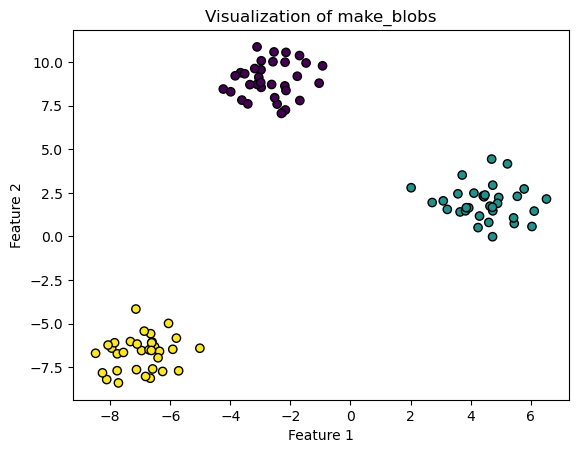

In [23]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate 2D blobs
X, y = make_blobs(n_samples=100, n_features=2, centers=3, random_state=42)

# Scatter plot
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Visualization of make_blobs')
plt.show()


In [45]:
X , Y = make_blobs(n_samples = 500 , centers = 2, n_features = 2,random_state = 10)
print(X.shape,Y.shape)

(500, 2) (500,)


In [15]:
Y


array([0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,

In [27]:
import seaborn as sns
sns.set_theme()

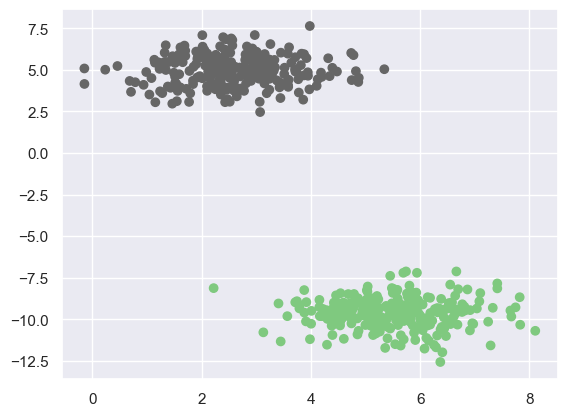

In [29]:
plt.scatter(X[:,0],X[:,1] , c = Y,cmap = plt.cm.Accent)
plt.show()

 ### Model And Helper Functions

In [31]:
def sigmoid(z):
    return 1.0/(1+np.exp(-z))

In [15]:
sigmoid(5)

0.9933071490757153

In [46]:
z = np.array([1,2,3,4,5])
sigmoid(z)  #an array will be implemented

array([0.26894142, 0.11920292, 0.04742587, 0.01798621, 0.00669285])

In [47]:
def predict(X,weights):
    #X = m x (n+1) matrix here +1 is for the bias  i.e.
    #weights = w = nx1 vector
    z = np.dot(X,weights)  #(W(transpose).X)
    predictions = sigmoid(z)

    return predictions

def loss(X,Y,weights):
    #Binary Cross Entropy
    #y hat is denoted by Y_
    Y_ = predict(X,weights)
    cost = np.mean(-Y*np.log(Y_) - (1-Y)*(np.log(1-Y_)))
    return cost

def update(X,Y,weights,learning_rate):
    Y_ = predict(X, weights)
    m = X.shape[0]
    dw = np.dot(X.T,Y_-Y)  #i.e. dJ(w)/dw
    weights = weights-learning_rate * dw/float(m)
    return weights


def train(X,Y,learning_rate,maxEpochs = 500):
    #we need to add the bias i.e. Xo as first col of the matrix i. e. 1 1 1 ....
    ones = np.ones((X.shape[0],1))
    X = np.hstack((ones,X))
    
    #Intitialize the x 
    weights = np.zeros(X.shape[1])

    for epoch in range(maxEpochs):
        weights = update(X,Y,weights,learning_rate)
        if(epoch%10)==0:
            l  = loss(X,Y,weights)
            print("Epoch number :%d and lost %.4f"%(epoch,l))

    return weights


w = train(X,Y,learning_rate = 0.01)
print("Trained Weights:", w)

Epoch number :0 and lost 0.5665
Epoch number :10 and lost 0.2029
Epoch number :20 and lost 0.1275
Epoch number :30 and lost 0.0937
Epoch number :40 and lost 0.0742
Epoch number :50 and lost 0.0616
Epoch number :60 and lost 0.0527
Epoch number :70 and lost 0.0460
Epoch number :80 and lost 0.0409
Epoch number :90 and lost 0.0368
Epoch number :100 and lost 0.0335
Epoch number :110 and lost 0.0307
Epoch number :120 and lost 0.0284
Epoch number :130 and lost 0.0264
Epoch number :140 and lost 0.0247
Epoch number :150 and lost 0.0232
Epoch number :160 and lost 0.0218
Epoch number :170 and lost 0.0206
Epoch number :180 and lost 0.0196
Epoch number :190 and lost 0.0186
Epoch number :200 and lost 0.0178
Epoch number :210 and lost 0.0170
Epoch number :220 and lost 0.0162
Epoch number :230 and lost 0.0156
Epoch number :240 and lost 0.0150
Epoch number :250 and lost 0.0144
Epoch number :260 and lost 0.0139
Epoch number :270 and lost 0.0134
Epoch number :280 and lost 0.0130
Epoch number :290 and los

In [78]:
one = np.ones((X.shape[0],1))

In [62]:
one

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],

np.ones(X.shape[0],1) is incorrect because np.ones() expects a tuple as the shape argument when specifying multiple dimensions.
X.shape[0] gives the number of rows in X, so it should be wrapped in parentheses: (X.shape[0], 1).

In [80]:
X = np.hstack((one,X))
X

array([[  1.        ,   5.83801528,  -9.29715058],
       [  1.        ,   5.67102739,  -9.76225984],
       [  1.        ,   3.15598083,   5.95298368],
       ...,
       [  1.        ,   5.655043  ,  -9.1398234 ],
       [  1.        ,   5.18645657, -10.28001766],
       [  1.        ,   4.34403119,   4.62483767]])

In [82]:
weights = np.zeros(X.shape[1])
weights

array([0., 0., 0.])

In [90]:
X

array([[  1.        ,   5.83801528,  -9.29715058],
       [  1.        ,   5.67102739,  -9.76225984],
       [  1.        ,   3.15598083,   5.95298368],
       ...,
       [  1.        ,   5.655043  ,  -9.1398234 ],
       [  1.        ,   5.18645657, -10.28001766],
       [  1.        ,   4.34403119,   4.62483767]])

In [15]:
np.zeros((3,1))

array([[0.],
       [0.],
       [0.]])